# Assignment 4: Regularization 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?
   - The intuition is that it will tame the feature space and control its complexity by adding a cost to the model that will boost the error.
2. How does regularization provide a way of exploring the bias-variance trade-off?
   - It is meant to see how we can take a complex model, which usually has lower bias and higher variance, and impose a penalty that will try to reduce the model's variance.
3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
   - LASSO sends the coefficients to zero and removes variables from the model to select a model specification for you while Ridge sends the coefficients a bit more smoothly and never completely removes variables. Lasso also has less smooth penalties than Ridge, having what is called "corners" at zero. Ridge is known to perform better due to these smooth applications, but LASSO is easier to interpret due to its very specific models.
4. How do we typically scale variables for use in regularized regression? Why?
   - We do this through normalization to ensure that each variable impacts the assignment the same amount. A way to do this is through z-score normalization, using cost functions to ensure that each plays a part in the model without being overpowering.
5. How is the penalty $\alpha$ typically selected?
   - We use cross validation to pick the appropriate alpha penalty value so that it will minimize the MSE. 
6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
   - uhefu

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 
2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero?
7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [3]:
# 2.1

df = pd.read_csv('./data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [5]:
df['Age'] = 2026 - df['Make_Year']
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,9
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,10
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,7
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,9
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,9


In [11]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly_features = ['Mileage_Run', 'Age']
X = df.loc[:, poly_features]
poly = PolynomialFeatures(degree = 3, include_bias = False)
X_poly = poly.fit_transform(X)
poly_names = poly.get_feature_names_out()
print(poly_names)

['Mileage_Run' 'Age' 'Mileage_Run^2' 'Mileage_Run Age' 'Age^2'
 'Mileage_Run^3' 'Mileage_Run^2 Age' 'Mileage_Run Age^2' 'Age^3']


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)
print("Scaled Data w/ z-score:", X_scaled)

Scaled Data w/ z-score: [[ 0.12469203 -0.01309242 -0.13767332 ... -0.23076715 -0.19558597
  -0.27042227]
 [-0.87233418  0.34185769 -0.79131562 ... -0.71818608 -0.56489035
   0.04408937]
 [-0.49351672 -0.72299265 -0.60062321 ... -0.64800377 -0.70091085
  -0.71839826]
 ...
 [ 0.46248973  1.05175792  0.19479598 ...  0.32073381  0.73673979
   0.88897673]
 [-0.54294553 -1.07794277 -0.62951357 ... -0.69364241 -0.80062127
  -0.86578933]
 [-0.01621083 -0.36804254 -0.25974731 ... -0.38445401 -0.42380175
  -0.52226369]]


In [14]:
# 2.2 

from sklearn.linear_model import LinearRegression

model1 = LinearRegression()
model1.fit(X_scaled, df['Price'])

print("Intercept:", model1.intercept_)
print('Score slope:', model1.coef_[0])

Intercept: 741019.4672131148
Score slope: 911774.8402226232


The sign for the interaction between *Mileage_Run* and *Age* is positive.

In [19]:
# 2.3

from sklearn.linear_model import LassoCV

alphas = np.logspace(1,3,20)
model2_3 = LassoCV(cv = 20, alphas = alphas, random_state = 100)
model = model2_3.fit(X_scaled, df['Price'])
lasso_alpha = model.alpha_
print("Lasso Alpha:", lasso_alpha)

Lasso Alpha: 69.51927961775606


c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.385e+10, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.463e+11, tolerance: 1.268e+10
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\emmy4\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, che

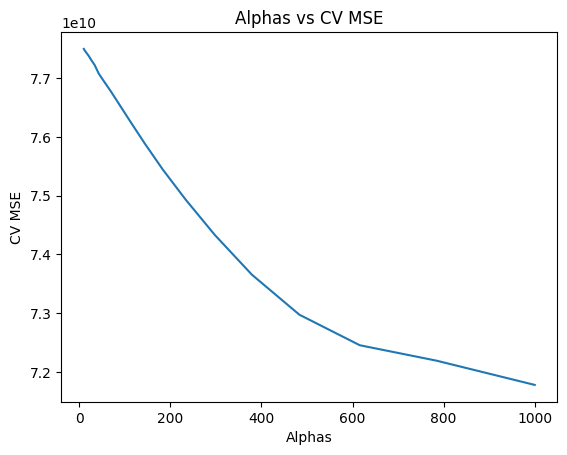

In [22]:
# 2.4

sns.lineplot(x = model.alphas_, y= np.median(model.mse_path_,axis=1))
plt.xlabel('Alphas')
plt.ylabel('CV MSE')
plt.title('Alphas vs CV MSE')
plt.show()

In [24]:
# 2.5

coefs = []
for alpha in alphas:
    model = LassoCV(alpha=alpha, max_iter = 1000)
    model = model.fit(X_poly,df['Price'])
    coefs.append(model.coef_)
coefs = np.array(coefs)

plt.figure()
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:,i], label=poly_names[i])

sns.lineplot(x = model.alphas_, y= np.median(model.coef_path_,axis=1))
plt.xlabel('Alphas')
plt.ylabel('COEF value')
plt.title('Lasso COEF paths')
plt.show()

TypeError: LassoCV.__init__() got an unexpected keyword argument 'alpha'. Did you mean 'alphas'?

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

In [25]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: './data/heart_failure_clinical_records_dataset.csv'

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?